<a href="https://colab.research.google.com/github/hkaido0718/SupportRestriction/blob/atsuki-iv_model/IVModel_Exclusion_Monotonicity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The `IVModel` class: exclusion and D-monotonicity with a binary instrument
Let $Y\in\{0,1\}$ denote an outcome, $D\in\{0,1\}$ a treatment, and $Z\in\{0,1\}$ an instrument. For example, $Y$ is employment, $D$ is participation in a training program, and $Z$ is a randomly assigned offer to participate. Let $D(z)$ and $Y(d,z)$ denote the potential treatment and the potential outcome, and suppose the observed responses are generated by $D=D(Z)$ and $Y=Y(D(Z),Z)$, where $Z$ is randomly assigned, so that the full vector $\big((Y(d,z))_{d,z},(D(z))_z\big)$ is independent of $Z$.

The `IVModel` class in `iv_model.py` represents three models, selected by two flags:

\begin{align}
&\text{Exclusion:}\qquad Y(d,z)=Y(d,z') \quad\text{for all } d \text{ and all } z,z';\\
&\text{D-monotonicity:}\qquad D(z)\leqslant_{a.s.} D(z') \quad\text{whenever } z<z'.
\end{align}

| Specification | `exclusion` | `d_monotonicity` |
|---|---|---|
| Exclusion only (the default) | `True` | `False` |
| D-monotonicity only | `False` | `True` |
| Both | `True` | `True` |

A further argument, `d_monotonicity_direction`, selects the direction of D-monotonicity: `"nondecreasing"` (the default, displayed above) or `"nonincreasing"`, which imposes $D(z)\geqslant_{a.s.} D(z')$ whenever $z<z'$. The section *Nonincreasing D-monotonicity* below demonstrates it.

No outcome monotonicity is imposed. Each model is represented by a graph $G$ whose nodes are the observable events $(y,d,z)$. `IVModel.build_graph()` constructs $G$ by Method 1 of Kaido and Ponomarev (2025), and the graph is then analyzed with the authors' `GraphAnalyzer`, exactly as in the other notebooks in this repository.

In [1]:
# Inside a local checkout, the modules are importable from the working directory.
# Anywhere else (for example Google Colab), fetch the repository, check out the
# branch or commit under review, and add it to the path.
import os
import sys

REPO_URL = "https://github.com/hkaido0718/SupportRestriction.git"
REPO_REF = "atsuki-iv_model"  # branch, tag or commit to load; use "main" once merged

if not os.path.isfile("iv_model.py"):
    if not os.path.isdir("SupportRestriction"):
        !git clone --quiet {REPO_URL}
    !git -C SupportRestriction checkout --quiet {REPO_REF}
    sys.path.insert(0, os.path.abspath("SupportRestriction"))

In [2]:
# Confirm which checkout the modules are imported from.
import subprocess

import iv_model
import graph_analysis_utils

for module in (iv_model, graph_analysis_utils):
    print(f"{module.__name__:21s} imported from {os.path.relpath(module.__file__)}")

repo_dir = os.path.dirname(os.path.abspath(iv_model.__file__))

def git(*args):
    result = subprocess.run(["git", "-C", repo_dir, *args], capture_output=True, text=True)
    return result.stdout.strip() or "?"

print(f"checkout: {git('rev-parse', '--abbrev-ref', 'HEAD')} at commit {git('rev-parse', '--short', 'HEAD')}")

iv_model              imported from iv_model.py
graph_analysis_utils  imported from graph_analysis_utils.py
checkout: atsuki-iv_model at commit e22d405


### Graph construction (Method 1 inside `IVModel`)
The researcher specifies the supports and the two flags. `build_graph()` adds every node $(y,d,z)$, visits each pair of nodes with different values of $z$ once, and joins the pair unless an enabled assumption rules out observing both events: exclusion rejects equal treatments with unequal outcomes, and D-monotonicity rejects a treatment that moves against the imposed direction as the instrument rises (under the default nondecreasing direction, a treatment that falls). Nodes with the same $z$ are never joined, because $D=D(Z)$ takes one value at a given $Z$.

In [3]:
import networkx as nx
from iv_model import IVModel
from graph_analysis_utils import GraphAnalyzer

specs = {
    "Exclusion only": dict(exclusion=True, d_monotonicity=False),
    "D-monotonicity only": dict(exclusion=False, d_monotonicity=True),
    "Both": dict(exclusion=True, d_monotonicity=True),
}
models = {
    name: IVModel(y_support=(0, 1), d_support=(0, 1), z_support=(0, 1), **flags)
    for name, flags in specs.items()
}
graphs = {name: model.build_graph() for name, model in models.items()}

for name, G in graphs.items():
    print(f"{name:20s} nodes = {G.number_of_nodes()}, edges = {G.number_of_edges()}")

Exclusion only       nodes = 8, edges = 12
D-monotonicity only  nodes = 8, edges = 12
Both                 nodes = 8, edges = 8


In [4]:
print(models["Both"].summary())

IVModel: discrete instrumental-variable model (Kaido and Ponomarev, 2025)
  Outcome support Y:    (0, 1)
  Treatment support D:  (0, 1)
  Instrument support Z: (0, 1)
  Nodes (y, d, z):      8
  Potential responses: D(z) and Y(d, z); observed D = D(Z), Y = Y(D(Z), Z).
  Assumptions:
    - Exclusion: imposed. Y(d, z) = Y(d, z') for every treatment value d and every pair of instrument values z, z'.
    - D-monotonicity: imposed, nondecreasing. D(z) <= D(z') whenever z < z' (treatment is nondecreasing in the instrument).
    - No outcome monotonicity is imposed.
  Maintained (not a pairwise rule): the full potential-response vector
    ((Y(d, z))_{d, z}, (D(z))_z) is independent of Z.
  Graph: build_graph() applies Method 1 (pairwise compatibility) and returns
    a networkx.Graph for GraphAnalyzer.


### Plot graphs
Each node is a triple $(y,d,z)$, coloured by the value of $z$. Exclusion removes the four edges joining equal treatments with unequal outcomes; D-monotonicity removes the four edges joining $d=1$ at $z=0$ with $d=0$ at $z=1$. The two sets are disjoint, so the third graph has eight edges.

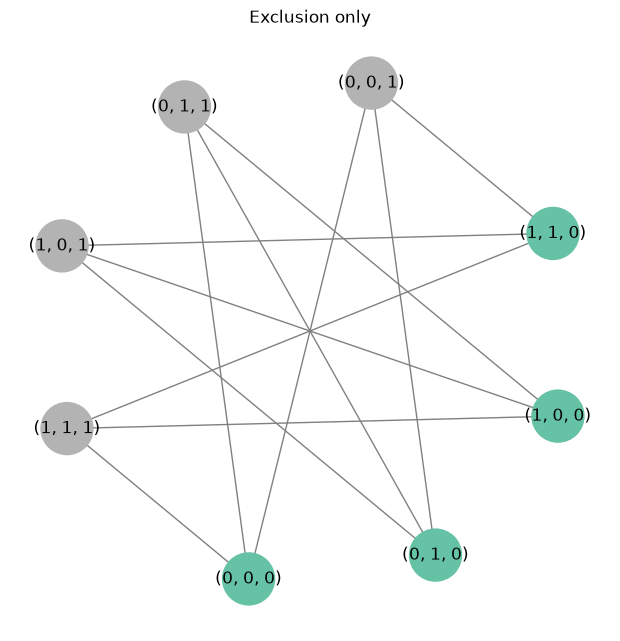

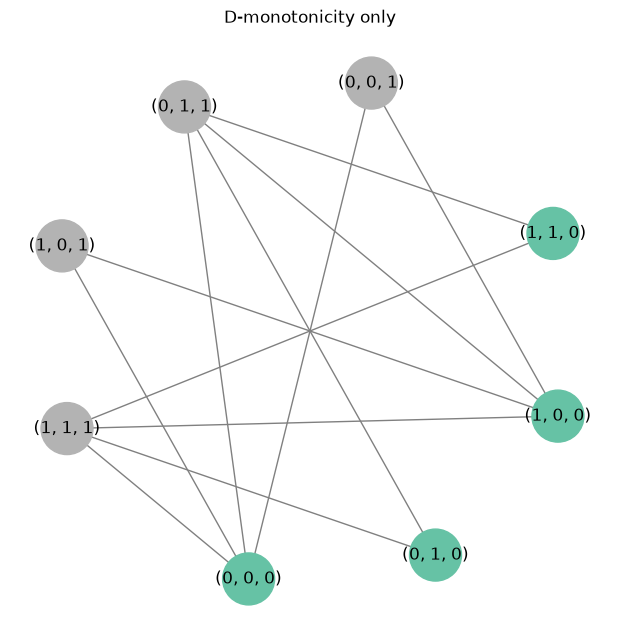

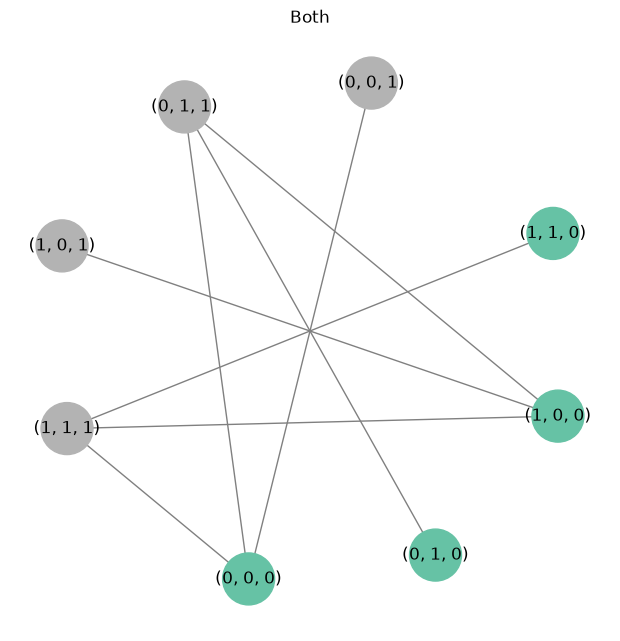

In [5]:
for name, model in models.items():
    analyzer = GraphAnalyzer(graphs[name], group_fn=model.group_fn)
    analyzer.plot_grouped_on_circle(title=name, node_size=1400)

### Get MIS and testable implications
Each maximal independent set $I$ of $G$ that is not contained in a single $z$-group gives the inequality $\sum_{(y,d,z)\in I} P(Y=y,D=d\mid Z=z)\leqslant 1$ (Theorem 1 of Kaido and Ponomarev, 2025): under random assignment $P(Y=y,D=d\mid Z=z)=P(Y(D(z),z)=y,D(z)=d)$, and the events for the nodes of $I$ are mutually exclusive because no admissible potential-response vector generates two of them.

In [6]:
for name, model in models.items():
    print(f"=== {name} ===")
    GraphAnalyzer(graphs[name], group_fn=model.group_fn).print_mis_excluding_single_group()

=== Exclusion only ===
Total MISs (excluding single-group ones): 4

1: [(0, 0, 1), (1, 0, 0)]
2: [(0, 0, 0), (1, 0, 1)]
3: [(0, 1, 1), (1, 1, 0)]
4: [(0, 1, 0), (1, 1, 1)]
=== D-monotonicity only ===
Total MISs (excluding single-group ones): 1

1: [(0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 0)]
=== Both ===
Total MISs (excluding single-group ones): 5

1: [(0, 0, 1), (0, 1, 0), (1, 0, 0), (1, 1, 0)]
2: [(0, 0, 0), (0, 1, 0), (1, 0, 1), (1, 1, 0)]
3: [(0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 0)]
4: [(0, 0, 1), (0, 1, 1), (1, 0, 1), (1, 1, 0)]
5: [(0, 0, 1), (0, 1, 0), (1, 0, 1), (1, 1, 1)]


**Exclusion only.** The four MISs are the pairs $\{(y,d,0),(1-y,d,1)\}$, giving

\begin{align}
P(Y=y,D=d\mid Z=0)+P(Y=1-y,D=d\mid Z=1)\leqslant 1,\qquad y,d\in\{0,1\},
\end{align}

the instrumental inequalities of Pearl (1995) for a binary instrument; see eq. (4.6) of Kaido and Ponomarev (2025) with $A=\{y\}$.

**D-monotonicity only.** The single MIS collects $D=1$ at $Z=0$ and $D=0$ at $Z=1$, both outcome values included: $P(D=1\mid Z=0)+P(D=0\mid Z=1)\leqslant 1$, that is, $P(D=1\mid Z=0)\leqslant P(D=1\mid Z=1)$. Outcomes place no restriction because $Y(d,z)$ is unrestricted.

**Both.** Five MISs. Four of them are the inequalities of Balke and Pearl (1997) and Kitagawa (2015),

\begin{align}
P(Y=y,D=1\mid Z=0)\leqslant P(Y=y,D=1\mid Z=1),\qquad P(Y=y,D=0\mid Z=1)\leqslant P(Y=y,D=0\mid Z=0),\qquad y\in\{0,1\},
\end{align}

in the form of eq. (4.7)-(4.8) of the paper. For example, the MIS printed fourth, $\{(0,0,1),(0,1,1),(1,0,1),(1,1,0)\}$, reads $P(D=0\mid Z=1)+P(Y=0,D=1\mid Z=1)+P(Y=1,D=1\mid Z=0)\leqslant 1$, which is the first inequality with $y=1$ because $P(D=0\mid Z=1)+P(Y=0,D=1\mid Z=1)=1-P(Y=1,D=1\mid Z=1)$. Each of these four tightens one exclusion-only inequality by adding $P(D=0\mid Z=1)$ or $P(D=1\mid Z=0)$ to its left-hand side, as Proposition 2 of the paper describes. The remaining MIS, printed third, collects $D=1$ at $Z=0$ and $D=0$ at $Z=1$ and is the monotonicity inequality $P(D=1\mid Z=0)\leqslant P(D=1\mid Z=1)$; it follows from summing the first displayed inequality over $y$ (the MISs printed fourth and fifth), so the list is complete but not irredundant (Remark 2 of the paper).

### Check regularity condition
With a binary instrument every support restriction is regular (Kaido and Ponomarev, 2025, Section 3.3): the graph is bipartite, hence perfect, and every maximal clique is a single edge, one node per value of $z$, which is a support point by the pairwise argument. We verify both conditions numerically with `is_perfect()` and the enumeration of the maximal cliques, checking that each contains exactly one node per instrument value. The ✅ marks only confirm that no pair inside a clique violates the enabled rules, which holds by construction of $G$. By Theorem 3 of the paper the MIS inequalities above are therefore sharp for each of the three models.

In [7]:
for name, model in models.items():
    analyzer = GraphAnalyzer(graphs[name], group_fn=model.group_fn)
    rows = analyzer.enumerate_cliques_and_check(model.violate_pairwise_fn)
    one_per_z = all(
        len({model.group_fn(v) for v in row["clique"]}) == len(model.z_support) for row in rows
    )
    print(f"=== {name}: perfect = {analyzer.is_perfect()}, maximal cliques = {len(rows)}, "
          f"one node per z in every clique = {one_per_z}")
    for row in rows:
        status = "✅" if row["satisfies_condition"] else "❌"
        print(f"{row['index']:>3}: {row['clique']} — {status}")

=== Exclusion only: perfect = True, maximal cliques = 12, one node per z in every clique = True
  1: [(1, 0, 0), (1, 0, 1)] — ✅
  2: [(1, 0, 1), (1, 1, 0)] — ✅
  3: [(0, 1, 0), (1, 0, 1)] — ✅
  4: [(0, 0, 0), (0, 0, 1)] — ✅
  5: [(0, 0, 0), (1, 1, 1)] — ✅
  6: [(0, 0, 0), (0, 1, 1)] — ✅
  7: [(0, 0, 1), (1, 1, 0)] — ✅
  8: [(0, 0, 1), (0, 1, 0)] — ✅
  9: [(1, 0, 0), (1, 1, 1)] — ✅
 10: [(1, 1, 0), (1, 1, 1)] — ✅
 11: [(0, 1, 1), (1, 0, 0)] — ✅
 12: [(0, 1, 0), (0, 1, 1)] — ✅
=== D-monotonicity only: perfect = True, maximal cliques = 12, one node per z in every clique = True
  1: [(1, 0, 0), (1, 0, 1)] — ✅
  2: [(0, 0, 1), (1, 0, 0)] — ✅
  3: [(1, 0, 0), (1, 1, 1)] — ✅
  4: [(0, 1, 1), (1, 0, 0)] — ✅
  5: [(0, 0, 0), (1, 0, 1)] — ✅
  6: [(0, 0, 0), (0, 0, 1)] — ✅
  7: [(0, 0, 0), (1, 1, 1)] — ✅
  8: [(0, 0, 0), (0, 1, 1)] — ✅
  9: [(1, 1, 0), (1, 1, 1)] — ✅
 10: [(0, 1, 1), (1, 1, 0)] — ✅
 11: [(0, 1, 0), (1, 1, 1)] — ✅
 12: [(0, 1, 0), (0, 1, 1)] — ✅
=== Both: perfect = True, maximal c

## Nonincreasing D-monotonicity
The constructor's last argument, `d_monotonicity_direction`, selects the direction of D-monotonicity. The default `"nondecreasing"` is the specification used above; `"nonincreasing"` imposes instead

\begin{align}
D(z)\geqslant_{a.s.} D(z') \quad\text{whenever } z<z',
\end{align}

so the pairwise rule rejects a treatment that *rises* as the instrument rises, while equal treatments are allowed in either direction. The value is validated whether or not `d_monotonicity` is `True`, but it changes the graph only when D-monotonicity is imposed. Reversing the order of the instrument values swaps the two directions: the nonincreasing graph on $Z\in\{0,1\}$ is the nondecreasing graph on $\{-1,0\}$ with $z$ relabelled as $-z$, so every result above has a mirror image in which the roles of $z=0$ and $z=1$ are exchanged. We build the two models that impose D-monotonicity in the nonincreasing direction, with and without exclusion.

In [8]:
specs_nonincreasing = {
    "D-monotonicity only (nonincreasing)": dict(
        exclusion=False, d_monotonicity=True, d_monotonicity_direction="nonincreasing"
    ),
    "Both (nonincreasing)": dict(
        exclusion=True, d_monotonicity=True, d_monotonicity_direction="nonincreasing"
    ),
}
models_nonincreasing = {
    name: IVModel(y_support=(0, 1), d_support=(0, 1), z_support=(0, 1), **flags)
    for name, flags in specs_nonincreasing.items()
}
graphs_nonincreasing = {name: model.build_graph() for name, model in models_nonincreasing.items()}

for name, G in graphs_nonincreasing.items():
    print(f"{name:36s} nodes = {G.number_of_nodes()}, edges = {G.number_of_edges()}")
print()
print(models_nonincreasing["Both (nonincreasing)"].summary())

D-monotonicity only (nonincreasing)  nodes = 8, edges = 12
Both (nonincreasing)                 nodes = 8, edges = 8

IVModel: discrete instrumental-variable model (Kaido and Ponomarev, 2025)
  Outcome support Y:    (0, 1)
  Treatment support D:  (0, 1)
  Instrument support Z: (0, 1)
  Nodes (y, d, z):      8
  Potential responses: D(z) and Y(d, z); observed D = D(Z), Y = Y(D(Z), Z).
  Assumptions:
    - Exclusion: imposed. Y(d, z) = Y(d, z') for every treatment value d and every pair of instrument values z, z'.
    - D-monotonicity: imposed, nonincreasing. D(z) >= D(z') whenever z < z' (treatment is nonincreasing in the instrument).
    - No outcome monotonicity is imposed.
  Maintained (not a pairwise rule): the full potential-response vector
    ((Y(d, z))_{d, z}, (D(z))_z) is independent of Z.
  Graph: build_graph() applies Method 1 (pairwise compatibility) and returns
    a networkx.Graph for GraphAnalyzer.


### Plot graphs
D-monotonicity now removes the four edges joining $d=0$ at $z=0$ with $d=1$ at $z=1$ (the complier pairs) instead of the four defier edges removed under the nondecreasing direction; with exclusion, the eight remaining edges are the never-taker, always-taker and defier pairs.

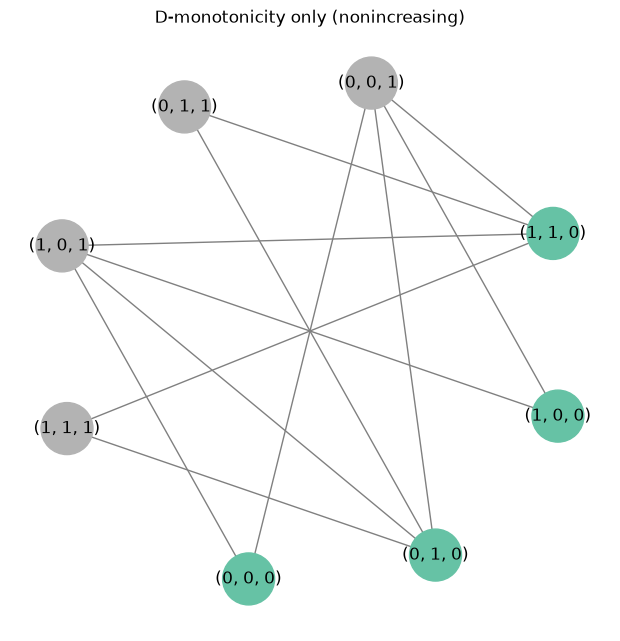

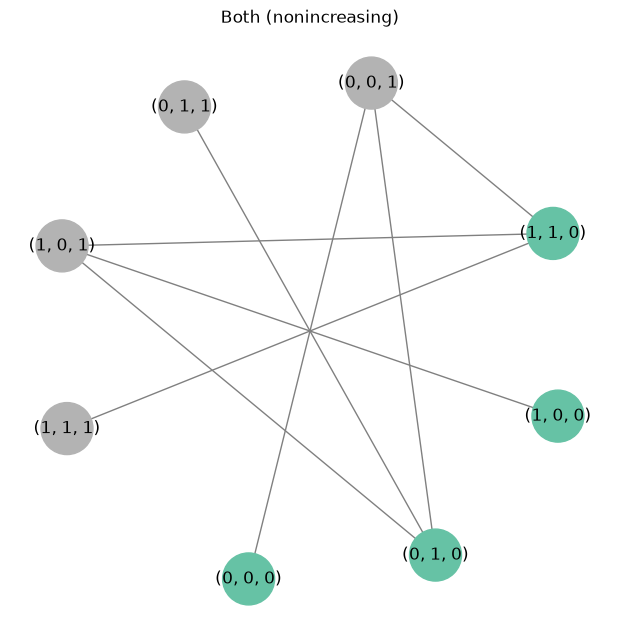

In [9]:
for name, model in models_nonincreasing.items():
    analyzer = GraphAnalyzer(graphs_nonincreasing[name], group_fn=model.group_fn)
    analyzer.plot_grouped_on_circle(title=name, node_size=1400)

### Get MIS and testable implications

In [10]:
for name, model in models_nonincreasing.items():
    print(f"=== {name} ===")
    GraphAnalyzer(graphs_nonincreasing[name], group_fn=model.group_fn).print_mis_excluding_single_group()

=== D-monotonicity only (nonincreasing) ===
Total MISs (excluding single-group ones): 1

1: [(0, 0, 0), (0, 1, 1), (1, 0, 0), (1, 1, 1)]
=== Both (nonincreasing) ===
Total MISs (excluding single-group ones): 5

1: [(0, 0, 0), (0, 1, 1), (1, 0, 0), (1, 1, 0)]
2: [(0, 0, 0), (0, 1, 0), (1, 0, 0), (1, 1, 1)]
3: [(0, 0, 0), (0, 1, 1), (1, 0, 0), (1, 1, 1)]
4: [(0, 0, 0), (0, 1, 1), (1, 0, 1), (1, 1, 1)]
5: [(0, 0, 1), (0, 1, 1), (1, 0, 0), (1, 1, 1)]


**D-monotonicity only (nonincreasing).** The single MIS collects $D=0$ at $Z=0$ and $D=1$ at $Z=1$, both outcome values included: $P(D=0\mid Z=0)+P(D=1\mid Z=1)\leqslant 1$, that is, $P(D=1\mid Z=1)\leqslant P(D=1\mid Z=0)$, the mirror image of the propensity-score inequality above.

**Both (nonincreasing).** Five MISs again. Four of them are the inequalities of Balke and Pearl (1997) and Kitagawa (2015) with the two instrument values exchanged,

\begin{align}
P(Y=y,D=1\mid Z=1)\leqslant P(Y=y,D=1\mid Z=0),\qquad P(Y=y,D=0\mid Z=0)\leqslant P(Y=y,D=0\mid Z=1),\qquad y\in\{0,1\},
\end{align}

and the fifth is the monotonicity inequality $P(D=1\mid Z=1)\leqslant P(D=1\mid Z=0)$, which again follows by summing the first displayed inequality over $y$.

### Check regularity condition
As before, the graph is bipartite, every maximal clique is one edge with one node per value of $z$, and the MIS inequalities are sharp.

In [11]:
for name, model in models_nonincreasing.items():
    analyzer = GraphAnalyzer(graphs_nonincreasing[name], group_fn=model.group_fn)
    rows = analyzer.enumerate_cliques_and_check(model.violate_pairwise_fn)
    one_per_z = all(
        len({model.group_fn(v) for v in row["clique"]}) == len(model.z_support) for row in rows
    )
    print(f"=== {name}: perfect = {analyzer.is_perfect()}, maximal cliques = {len(rows)}, "
          f"one node per z in every clique = {one_per_z}, "
          f"every clique passes the pairwise check = {all(row['satisfies_condition'] for row in rows)}")

=== D-monotonicity only (nonincreasing): perfect = True, maximal cliques = 12, one node per z in every clique = True, every clique passes the pairwise check = True
=== Both (nonincreasing): perfect = True, maximal cliques = 8, one node per z in every clique = True, every clique passes the pairwise check = True


## A three-valued instrument: exclusion alone is not regular
The pairwise rules do not depend on the number of instrument values, so the same class handles $Z\in\{0,1,2\}$. Exclusion alone is the notable non-regular case in the paper (Section 3.3 and Appendix D.3.1): its graph has 12 nodes, 36 edges, 28 maximal cliques, and 15 MISs including the three single-group parts, matching Table 4 of the paper, but it contains an odd hole, so the MIS inequalities are not sharp and the higher-level inequalities counted in Table 4 (24 inequalities of level 2 and 3) are needed. Adding D-monotonicity removes 12 edges and the graph becomes perfect (a comparability graph, Appendix B.1 of the paper), so its 23 MIS inequalities are sharp. The nonincreasing direction gives the mirror image of that graph (relabel $z$ as $2-z$), with the same counts and the same perfectness.

In [12]:
specs_three_valued = {
    "Exclusion only": specs["Exclusion only"],
    "Both": specs["Both"],
    "Both (nonincreasing)": specs_nonincreasing["Both (nonincreasing)"],
}
for name, flags in specs_three_valued.items():
    model = IVModel(y_support=(0, 1), d_support=(0, 1), z_support=(0, 1, 2), **flags)
    G = model.build_graph()
    analyzer = GraphAnalyzer(G, group_fn=model.group_fn)
    n_mis = len(analyzer.find_mis_excluding_single_group())
    n_cliques = len(list(nx.find_cliques(G)))
    print(f"{name:21s} nodes = {G.number_of_nodes()}, edges = {G.number_of_edges()}, "
          f"maximal cliques = {n_cliques}, MISs excluding single-group ones = {n_mis}, "
          f"perfect = {analyzer.is_perfect()}")

Exclusion only        nodes = 12, edges = 36, maximal cliques = 28, MISs excluding single-group ones = 12, perfect = False


Both                  nodes = 12, edges = 24, maximal cliques = 12, MISs excluding single-group ones = 23, perfect = True


Both (nonincreasing)  nodes = 12, edges = 24, maximal cliques = 12, MISs excluding single-group ones = 23, perfect = True


The tests in `tests/test_iv_model.py` check the counts and edges above for both monotonicity directions and compare Method 1 with an enumeration of all potential-response vectors (Method 2); `iv_model_handover.md` gives the argument behind the pairwise rules.